### lesson \#19 by Storchak Vasyl

In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import platform
import plotly.graph_objects as go
import kagglehub

from sklearn.preprocessing import LabelEncoder
from factor_analyzer import FactorAnalyzer
from factor_analyzer.factor_analyzer import calculate_kmo, calculate_bartlett_sphericity
from scipy.stats import ttest_ind

### Task 1

In [16]:
# LINK ON DATASET DONT WORK! 
# i give data from https://www.kaggle.com/datasets/romanniki/light-theme-and-dark-theme-case-study?resource=download

In [2]:
path = kagglehub.dataset_download("romanniki/light-theme-and-dark-theme-case-study")
print("Path to dataset files:", path)

Path to dataset files: /home/forever/.cache/kagglehub/datasets/romanniki/light-theme-and-dark-theme-case-study/versions/1


In [3]:
df = pd.read_csv('/home/forever/.cache/kagglehub/datasets/romanniki/'\
                      'light-theme-and-dark-theme-case-study/versions/1/website_ab_test.csv')
df.head(3)

,Theme,Click Through Rate,Conversion Rate,Bounce Rate,Scroll_Depth,Age,Location,Session_Duration,Purchases,Added_to_Cart
0,Light Theme,0.054920,0.282367,0.405085,72.489458,25,Chennai,1535,No,Yes
1,Light Theme,0.113932,0.032973,0.732759,61.858568,19,Pune,303,No,Yes
2,Dark Theme,0.323352,0.178763,0.296543,45.737376,47,Chennai,563,Yes,Yes


In [13]:
summary = {
    'Number of Records': df.shape[0],
    'Number of Columns': df.shape[1],
    'Missing Values': df.isnull().sum(),
    'Summary': df.describe()
}
summary

{'Number of Records': 1000,
 'Number of Columns': 10,
 'Missing Values': Theme                 0
 Click Through Rate    0
 Conversion Rate       0
 Bounce Rate           0
 Scroll_Depth          0
 Age                   0
 Location              0
 Session_Duration      0
 Purchases             0
 Added_to_Cart         0
 dtype: int64,
 'Summary':        Click Through Rate  Conversion Rate  Bounce Rate  Scroll_Depth  \
 count         1000.000000      1000.000000  1000.000000   1000.000000   
 mean             0.256048         0.253312     0.505758     50.319494   
 std              0.139265         0.139092     0.172195     16.895269   
 min              0.010767         0.010881     0.200720     20.011738   
 25%              0.140794         0.131564     0.353609     35.655167   
 50%              0.253715         0.252823     0.514049     51.130712   
 75%              0.370674         0.373040     0.648557     64.666258   
 max              0.499989         0.498916     0.799658    

,Click Through Rate,Conversion Rate,Bounce Rate,Scroll_Depth,Age,Session_Duration
Theme,,,,,,
Dark Theme,0.264501,0.251282,0.512115,49.926404,41.332685,919.482490
Light Theme,0.247109,0.255459,0.499035,50.735232,41.734568,930.833333


### H0 & H1

In [20]:
numeric_columns = df.select_dtypes(include=['number']).columns
theme_performance = df.groupby('Theme')[numeric_columns].mean()

theme_performance

,Click Through Rate,Conversion Rate,Bounce Rate,Scroll_Depth,Age,Session_Duration
Theme,,,,,,
Dark Theme,0.264501,0.251282,0.512115,49.926404,41.332685,919.482490
Light Theme,0.247109,0.255459,0.499035,50.735232,41.734568,930.833333


In [ ]:
# formulate H0
# H0: μ_light = μ_dark

In [ ]:
# formulate H1
# H1: μ_light != μ_dark

In [48]:
percent_diff = abs(((theme_performance.loc["Dark Theme"] - \
                     theme_performance.loc["Light Theme"]) / \
                     theme_performance.loc["Light Theme"]) * 100)

In [49]:
percent_diff

Click Through Rate    7.038259
Conversion Rate       1.635228
Bounce Rate           2.621035
Scroll_Depth          1.594213
Age                   0.962950
Session_Duration      1.219428
dtype: float64

In [69]:
percent_diff.abs().mean()

2.511852326426071

### statistical testing

In [ ]:
# first view
# different data is 2.5%, in margin of error
# i can tell H0 is TRUE

In [74]:
conversion_rates_light = df[df['Theme'] == 'Light Theme']['Conversion Rate']
conversion_rates_dark = df[df['Theme'] == 'Dark Theme']['Conversion Rate']

# performing a two-sample t-test
t_stat, p_value = ttest_ind(conversion_rates_light, conversion_rates_dark, equal_var=False)

print(f"t-statistic: {t_stat:.5f}")
print(f"p-value:     {p_value:.5f}")

t-statistic: 0.47485
p-value:     0.63500


### Conclusion
#### p-value more then 5% (0.05), i confirm H0

### interpretation

#### дані в межах статистичної похибки, є різниця хіба що в коєф. кліків в сторону темної теми (7%)

### Task 2

In [83]:
# prep. data
path = kagglehub.dataset_download("mirichoi0218/insurance")
path

'/home/forever/.cache/kagglehub/datasets/mirichoi0218/insurance/versions/1'

#### data exploration

In [84]:
df = pd.read_csv('/home/forever/.cache/kagglehub/datasets/mirichoi0218/insurance/versions/1/insurance.csv')
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [85]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [86]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


#### outlier detection

Text(0, 0.5, 'Count of people')

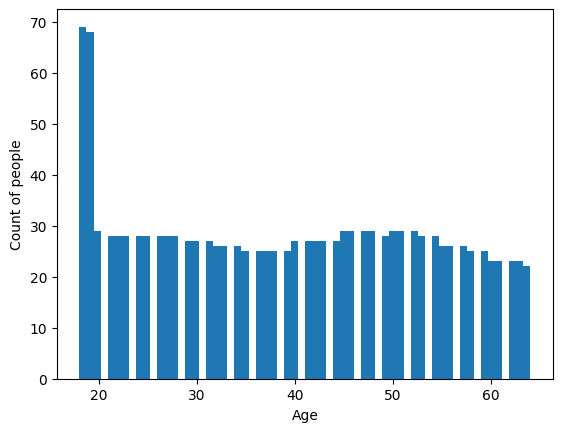

In [87]:
# age visualize
plt.hist(df['age'], bins=df['age'].max())
plt.xlabel('Age')
plt.ylabel('Count of people')

In [88]:
u_age = df['age'].sort_values().unique()
print(u_age)

[18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41
 42 43 44 45 46 47 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64]


#### more people aged 18 and 19

Text(0, 0.5, 'Count of people')

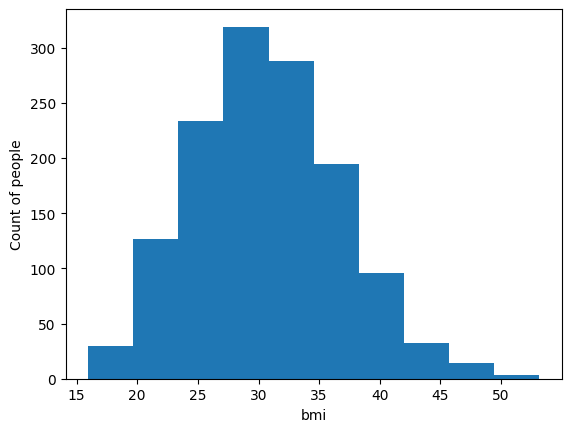

In [89]:
plt.hist(df['bmi']) #, bins=df['bmi'].max())
plt.xlabel('bmi')
plt.ylabel('Count of people')

#### normal of distribution of bmi
#### *many people are fat (normal is 19-25)

Text(0, 0.5, 'Count of people')

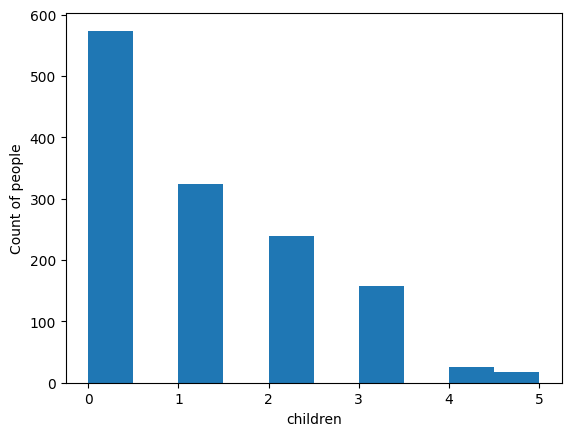

In [90]:
plt.hist(df['children']) #, bins=df['bmi'].max())
plt.xlabel('children')
plt.ylabel('Count of people')

#### more families have one children

Text(0, 0.5, 'Count')

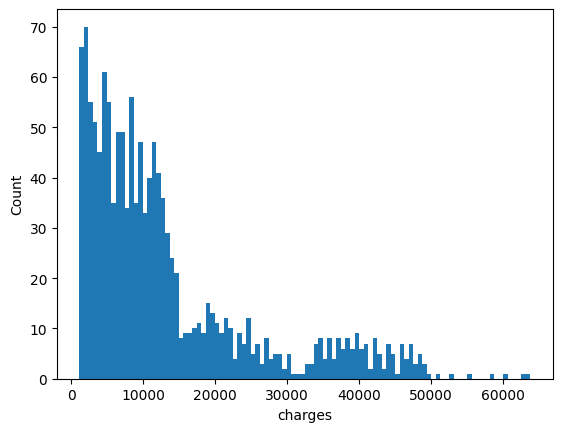

In [91]:
plt.hist(df['charges'], bins=100)
plt.xlabel('charges')
plt.ylabel('Count')

In [92]:
df['charges'].describe()

count     1338.000000
mean     13270.422265
std      12110.011237
min       1121.873900
25%       4740.287150
50%       9382.033000
75%      16639.912515
max      63770.428010
Name: charges, dtype: float64

#### not normal distribution, shift to left

In [93]:
df['smoker'].describe()

count     1338
unique       2
top         no
freq      1064
Name: smoker, dtype: object

In [94]:
df['smoker'].unique()

array(['yes', 'no'], dtype=object)

In [95]:
# smoker <-> non smoker
df['smoker'].value_counts().get('yes'), df['smoker'].value_counts().get('no')

(274, 1064)

In [96]:
df['region'].describe()

count          1338
unique            4
top       southeast
freq            364
Name: region, dtype: object

In [97]:
df['region'].unique()

array(['southwest', 'southeast', 'northwest', 'northeast'], dtype=object)

In [98]:
for region in df['region'].unique():
    print(f"region: {region}, count: {df['region'].value_counts().get(region)}")

region: southwest, count: 325
region: southeast, count: 364
region: northwest, count: 325
region: northeast, count: 324


#### +- uniform distribution, except southeast (+30 items)

In [99]:
df['sex'].describe()

count     1338
unique       2
top       male
freq       676
Name: sex, dtype: object

In [100]:
df['sex'].unique()

array(['female', 'male'], dtype=object)

In [101]:
df['sex'].value_counts().get('female'), df['sex'].value_counts().get('male')

(662, 676)

#### uniform destribution

#### data cleaning

In [102]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [103]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [104]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


#### i think need cast all data to integer type for make less dataset and more comfort data manipulation

In [105]:
# using function from sklearn

In [106]:
encoder = LabelEncoder()

In [107]:
df["sex"] = encoder.fit_transform(df["sex"])
df["smoker"] = encoder.fit_transform(df["smoker"])
df["region"] = encoder.fit_transform(df["region"])

In [108]:
df['sex'].unique()

array([0, 1])

In [109]:
df['smoker'].unique()

array([1, 0])

In [110]:
df['region'].unique()

array([3, 2, 1, 0])

In [111]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,3,16884.92400
1,18,1,33.770,1,0,2,1725.55230
2,28,1,33.000,3,0,2,4449.46200
3,33,1,22.705,0,0,1,21984.47061
4,32,1,28.880,0,0,1,3866.85520


In [112]:
df['bmi'] = df['bmi'].astype(int)
df['charges'] = df['charges'].astype(int)

In [113]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,0,27,0,1,3,16884
1,18,1,33,1,0,2,1725
2,28,1,33,3,0,2,4449
3,33,1,22,0,0,1,21984
4,32,1,28,0,0,1,3866


In [114]:
# check outliners with IQR method

In [115]:
# for check outliners data
def find_outliers_iqr(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return series[(series < lower) | (series > upper)]

In [116]:
# for check index outliners
def iqr_bounds(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return lower, upper

In [117]:
outliers = list()

for col in ["age", "bmi", "charges"]:
    outliers.append(find_outliers_iqr(df[col]))

In [118]:
outliers

[Series([], Name: age, dtype: int64),
 116     49
 286     48
 401     47
 543     47
 847     50
 860     47
 1047    52
 1088    47
 1317    53
 Name: bmi, dtype: int64,
 14      39611
 19      36837
 23      37701
 29      38711
 30      35585
         ...  
 1300    62592
 1301    46718
 1303    37829
 1313    36397
 1323    43896
 Name: charges, Length: 139, dtype: int64]

In [119]:
low_bmi, high_bmi = iqr_bounds(df["bmi"])
low_ch, high_ch = iqr_bounds(df["charges"])

df = df[(df["bmi"] >= low_bmi) & (df["bmi"] <= high_bmi)]
df = df[(df["charges"] >= low_ch) & (df["charges"] <= high_ch)]

In [120]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1193 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   age       1193 non-null   int64
 1   sex       1193 non-null   int64
 2   bmi       1193 non-null   int64
 3   children  1193 non-null   int64
 4   smoker    1193 non-null   int64
 5   region    1193 non-null   int64
 6   charges   1193 non-null   int64
dtypes: int64(7)
memory usage: 74.6 KB


In [121]:
df = df.reset_index(drop=True)

In [122]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1193 entries, 0 to 1192
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   age       1193 non-null   int64
 1   sex       1193 non-null   int64
 2   bmi       1193 non-null   int64
 3   children  1193 non-null   int64
 4   smoker    1193 non-null   int64
 5   region    1193 non-null   int64
 6   charges   1193 non-null   int64
dtypes: int64(7)
memory usage: 65.4 KB


#### done

### Task 3

In [177]:
# download from link -> https://www.kaggle.com/code/francoisstamant/eda-and-factor-analysis/input
# data preparation

In [123]:
df3 = pd.read_csv('test.csv')

In [124]:
df3.head()

,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,19556,Female,Loyal Customer,52,Business travel,Eco,160,5,4,...,5,5,5,5,2,5,5,50,44.0,satisfied
1,1,90035,Female,Loyal Customer,36,Business travel,Business,2863,1,1,...,4,4,4,4,3,4,5,0,0.0,satisfied
2,2,12360,Male,disloyal Customer,20,Business travel,Eco,192,2,0,...,2,4,1,3,2,2,2,0,0.0,neutral or dissatisfied
3,3,77959,Male,Loyal Customer,44,Business travel,Business,3377,0,0,...,1,1,1,1,3,1,4,0,6.0,satisfied
4,4,36875,Female,Loyal Customer,49,Business travel,Eco,1182,2,3,...,2,2,2,2,4,2,4,0,20.0,satisfied


In [125]:
df3.describe()

,Unnamed: 0,id,Age,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes
count,25976.000000,25976.000000,25976.000000,25976.000000,25976.000000,25976.000000,25976.000000,25976.000000,25976.000000,25976.000000,25976.000000,25976.000000,25976.000000,25976.000000,25976.000000,25976.000000,25976.000000,25976.000000,25976.00000,25893.000000
mean,12987.500000,65005.657992,39.620958,1193.788459,2.724746,3.046812,2.756775,2.977094,3.215353,3.261665,3.449222,3.357753,3.385664,3.350169,3.633238,3.314175,3.649253,3.286226,14.30609,14.740857
std,7498.769632,37611.526647,15.135685,998.683999,1.335384,1.533371,1.412951,1.282133,1.331506,1.355536,1.320090,1.338299,1.282088,1.318862,1.176525,1.269332,1.180681,1.319330,37.42316,37.517539
min,0.000000,17.000000,7.000000,31.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.00000,0.000000
25%,6493.750000,32170.500000,27.000000,414.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,3.000000,3.000000,3.000000,2.000000,0.00000,0.000000
50%,12987.500000,65319.500000,40.000000,849.000000,3.000000,3.000000,3.000000,3.000000,3.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,3.000000,4.000000,3.000000,0.00000,0.000000
75%,19481.250000,97584.250000,51.000000,1744.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,5.000000,4.000000,4.000000,4.000000,5.000000,4.000000,5.000000,4.000000,12.00000,13.000000
max,25975.000000,129877.000000,85.000000,4983.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,1128.00000,1115.000000


In [126]:
df3.columns

Index(['Unnamed: 0', 'id', 'Gender', 'Customer Type', 'Age', 'Type of Travel',
       'Class', 'Flight Distance', 'Inflight wifi service',
       'Departure/Arrival time convenient', 'Ease of Online booking',
       'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort',
       'Inflight entertainment', 'On-board service', 'Leg room service',
       'Baggage handling', 'Checkin service', 'Inflight service',
       'Cleanliness', 'Departure Delay in Minutes', 'Arrival Delay in Minutes',
       'satisfaction'],
      dtype='object')

In [127]:
df3.drop(['Unnamed: 0', 'id', ], axis=1, inplace=True)

In [128]:
df3.columns

Index(['Gender', 'Customer Type', 'Age', 'Type of Travel', 'Class',
       'Flight Distance', 'Inflight wifi service',
       'Departure/Arrival time convenient', 'Ease of Online booking',
       'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort',
       'Inflight entertainment', 'On-board service', 'Leg room service',
       'Baggage handling', 'Checkin service', 'Inflight service',
       'Cleanliness', 'Departure Delay in Minutes', 'Arrival Delay in Minutes',
       'satisfaction'],
      dtype='object')

In [129]:
df3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25976 entries, 0 to 25975
Data columns (total 23 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Gender                             25976 non-null  object 
 1   Customer Type                      25976 non-null  object 
 2   Age                                25976 non-null  int64  
 3   Type of Travel                     25976 non-null  object 
 4   Class                              25976 non-null  object 
 5   Flight Distance                    25976 non-null  int64  
 6   Inflight wifi service              25976 non-null  int64  
 7   Departure/Arrival time convenient  25976 non-null  int64  
 8   Ease of Online booking             25976 non-null  int64  
 9   Gate location                      25976 non-null  int64  
 10  Food and drink                     25976 non-null  int64  
 11  Online boarding                    25976 non-null  int

In [130]:
df3.iloc[:,21].isna().sum()

83

In [131]:
df3 = df3.dropna()

In [132]:
df3.info()

<class 'pandas.core.frame.DataFrame'>
Index: 25893 entries, 0 to 25975
Data columns (total 23 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Gender                             25893 non-null  object 
 1   Customer Type                      25893 non-null  object 
 2   Age                                25893 non-null  int64  
 3   Type of Travel                     25893 non-null  object 
 4   Class                              25893 non-null  object 
 5   Flight Distance                    25893 non-null  int64  
 6   Inflight wifi service              25893 non-null  int64  
 7   Departure/Arrival time convenient  25893 non-null  int64  
 8   Ease of Online booking             25893 non-null  int64  
 9   Gate location                      25893 non-null  int64  
 10  Food and drink                     25893 non-null  int64  
 11  Online boarding                    25893 non-null  int64  


In [133]:
df3['satisfaction'].unique()

array(['satisfied', 'neutral or dissatisfied'], dtype=object)

In [136]:
encoder = LabelEncoder()

for col in ["satisfaction", "Class", "Gender", "Customer Type", "Type of Travel"]:
    df3[col] = encoder.fit_transform(df3[col])

In [137]:
df3['satisfaction'].unique()

array([1, 0])

In [139]:
df3.info()

<class 'pandas.core.frame.DataFrame'>
Index: 25893 entries, 0 to 25975
Data columns (total 23 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Gender                             25893 non-null  int64  
 1   Customer Type                      25893 non-null  int64  
 2   Age                                25893 non-null  int64  
 3   Type of Travel                     25893 non-null  int64  
 4   Class                              25893 non-null  int64  
 5   Flight Distance                    25893 non-null  int64  
 6   Inflight wifi service              25893 non-null  int64  
 7   Departure/Arrival time convenient  25893 non-null  int64  
 8   Ease of Online booking             25893 non-null  int64  
 9   Gate location                      25893 non-null  int64  
 10  Food and drink                     25893 non-null  int64  
 11  Online boarding                    25893 non-null  int64  


In [140]:
df3['Gender'].unique()

array([0, 1])

In [141]:
df3['Customer Type'].unique()

array([0, 1])

In [142]:
df3['Type of Travel'].unique()

array([0, 1])

In [143]:
df3['Class'].unique()

array([1, 0, 2])

In [144]:
df3['Arrival Delay in Minutes'] = df3['Arrival Delay in Minutes'].astype(int)

In [145]:
df3.info()

<class 'pandas.core.frame.DataFrame'>
Index: 25893 entries, 0 to 25975
Data columns (total 23 columns):
 #   Column                             Non-Null Count  Dtype
---  ------                             --------------  -----
 0   Gender                             25893 non-null  int64
 1   Customer Type                      25893 non-null  int64
 2   Age                                25893 non-null  int64
 3   Type of Travel                     25893 non-null  int64
 4   Class                              25893 non-null  int64
 5   Flight Distance                    25893 non-null  int64
 6   Inflight wifi service              25893 non-null  int64
 7   Departure/Arrival time convenient  25893 non-null  int64
 8   Ease of Online booking             25893 non-null  int64
 9   Gate location                      25893 non-null  int64
 10  Food and drink                     25893 non-null  int64
 11  Online boarding                    25893 non-null  int64
 12  Seat comfort           

#### Factor Analysis

In [215]:
rating_cols = [
    'Inflight wifi service', 'Departure/Arrival time convenient',
    'Ease of Online booking', 'Gate location', 'Food and drink',
    'Online boarding', 'Seat comfort', 'Inflight entertainment',
    'On-board service', 'Leg room service', 'Baggage handling',
    'Checkin service', 'Inflight service', 'Cleanliness'
]

In [216]:
r_df = df3[rating_cols]

In [221]:
kmo_all, kmo_model = calculate_kmo(r_df)
kmo_all, kmo_model

(array([0.74702472, 0.75415392, 0.68847618, 0.70538572, 0.8415912 ,
        0.73247909, 0.82657663, 0.76824406, 0.83079545, 0.8875923 ,
        0.81750041, 0.69524858, 0.78649311, 0.82269756]),
 0.7825563951174126)

In [222]:
chi_square_value, p_value = calculate_bartlett_sphericity(r_df)
chi_square_value, p_value

(151817.62779745305, 0.0)

In [223]:
fa = FactorAnalyzer(rotation=None)
fa.fit(r_df)

/home/forever/.local/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


FactorAnalyzer(rotation=None, rotation_kwargs={})

In [224]:
ev, v = fa.get_eigenvalues()

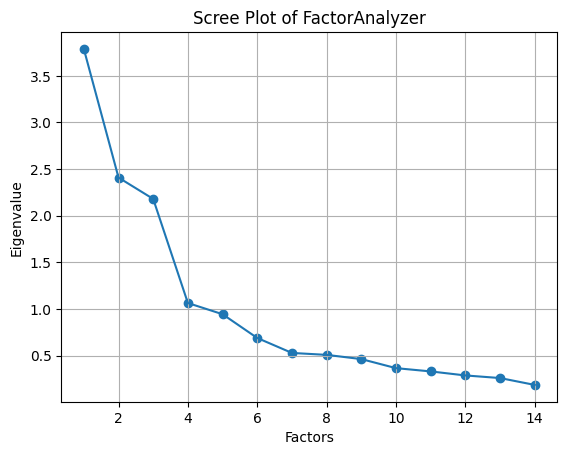

In [226]:
plt.scatter(range(1, r_df.shape[1] + 1), ev)
plt.plot(range(1, r_df.shape[1] + 1), ev)
plt.title('Scree Plot of FactorAnalyzer')
plt.xlabel('Factors')
plt.ylabel('Eigenvalue')
plt.grid(True)

In [227]:
n_factors = sum(ev > 1)
"Number of factors by Kaiser", n_factors

('Number of factors by Kaiser', 4)

In [228]:
fa = FactorAnalyzer(n_factors=n_factors, rotation='varimax')
fa.fit(r_df)

/home/forever/.local/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


FactorAnalyzer(n_factors=4, rotation='varimax', rotation_kwargs={})

In [229]:
loadings = pd.DataFrame(fa.loadings_, index=rating_cols, columns=[f'Factor{i+1}' for i in range(n_factors)])
print(loadings)

                                    Factor1   Factor2   Factor3   Factor4
Inflight wifi service              0.091896  0.128891  0.624220  0.451994
Departure/Arrival time convenient -0.023692  0.049061  0.589979 -0.002223
Ease of Online booking            -0.031748  0.031127  0.774826  0.428406
Gate location                      0.012579 -0.051511  0.694897 -0.122430
Food and drink                     0.772919  0.001546  0.020379  0.039239
Online boarding                    0.278920  0.113642  0.126602  0.762008
Seat comfort                       0.760206  0.070242 -0.028883  0.216673
Inflight entertainment             0.776624  0.462511  0.039810  0.023605
On-board service                   0.080347  0.705060  0.009740  0.051839
Leg room service                   0.060343  0.490631  0.049851  0.090025
Baggage handling                   0.043092  0.767760  0.043618 -0.027719
Checkin service                    0.099927  0.291556 -0.039033  0.150804
Inflight service                   0.0

In [231]:
# show factors
for i in range(n_factors):
    print(f"\nFactor {i+1}:")
    print(loadings.iloc[:, i].sort_values(ascending=False))


Factor 1:
Cleanliness                          0.851640
Inflight entertainment               0.776624
Food and drink                       0.772919
Seat comfort                         0.760206
Online boarding                      0.278920
Checkin service                      0.099927
Inflight wifi service                0.091896
On-board service                     0.080347
Leg room service                     0.060343
Inflight service                     0.045902
Baggage handling                     0.043092
Gate location                        0.012579
Departure/Arrival time convenient   -0.023692
Ease of Online booking              -0.031748
Name: Factor1, dtype: float64

Factor 2:
Inflight service                     0.798636
Baggage handling                     0.767760
On-board service                     0.705060
Leg room service                     0.490631
Inflight entertainment               0.462511
Checkin service                      0.291556
Inflight wifi service       

# CONCLUSION

In [ ]:
# factor 1 - авіакомпанії можуть краще розтавити пріоритети для надання послуг
# factor 2 - покращення послуг під час польоту, багаж, місце для ніг, і тд.
# factor 3 - важливість онлайн бронювання та місця локації
# factor 4 - онлайн посадка та хороший інтернет
# ps. можна зробити висновок що отримання послуг має бути через інтернет та має бути віфі, після надання основних послуг